# Topic analysis

Group 52, XB_0085 Text Mining

Test set: Sentiment-topic-test.tsv, labels are movie, restaurant, book. We did not have training data for these three so we wrote one ourselves (data/topic_classification.csv, around 30 sentences per topic). Two classifiers, Naive Bayes on bag of words + tf-idf as a baseline, and a fine tuned BERT on top of that. The BERT hyperparameters are the same ones we used in sentiment.ipynb.

In [11]:
import pandas as pd

df = pd.read_csv('../data/Sentiment-topic-test.tsv', sep='\t')

test_df = pd.DataFrame({'text': df.text,
                      'labels':  [0 if t.strip() == "book" else 1 if t.strip() == "movie" else 2 for t in df.topic]})

df.head()

,sentence id,text,sentiment,topic
0,0,It took eight years for Warner Brothers to rec...,negative,movie
1,1,All the New York University students love this...,positive,restaurant
2,2,This Italian place is really trendy but they h...,negative,restaurant
3,3,"In conclusion, my review of this book would be...",positive,book
4,4,The story of this movie is focused on Carl Bra...,neutral,movie


In [12]:
# load training data
import pandas as pd
from sklearn.model_selection import train_test_split

raw_data = pd.read_csv('../data/topic_classification.csv')

train = pd.DataFrame({'text': raw_data.text,
                      'labels': [0 if t.strip() == "book" else 1 if t.strip() == "movie" else 2 for t in raw_data.topic]})

# Split data for a dev set
train, dev = train_test_split(train, test_size=0.15, random_state=0,
                              stratify=train['labels'])

print(train)

                                                 text  labels
12  The ending was rushed and left too many things...       1
32  The menu is way too big half the things were n...       2
34  The waiter recommended the daily special and i...       2
74  The plot is predictable but the characters are...       0
69  The protagonist's inner monologue dragged on f...       0
..                                                ...     ...
1   I walked out of the cinema thinking about it f...       1
68  This is the third book in the series and the w...       0
79  The Kindle version has a few typos but otherwi...       0
45  They take reservations only on weekends which ...       2
64  The author's style feels very influenced by He...       0

[76 rows x 2 columns]


## Naive Bayes

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

nltk_stopwords = stopwords.words('english')

count_vect = CountVectorizer(stop_words=nltk_stopwords)
X_train_counts = count_vect.fit_transform(train['text'])

tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

nb = MultinomialNB()
nb.fit(X_train_tfidf, train['labels'])

[nltk_data] Downloading package stopwords to /Users/jasp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


MultinomialNB()

## Fine tuned BERT

/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/simpletransformers/classification/classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(


0it [00:00, ?it/s]

/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Running Epoch 1 of 2:   0%|          | 0/5 [00:00<?, ?it/s]

...

0it [00:00, ?it/s]

/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Running Evaluation:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

              precision    recall  f1-score   support

        book       0.00      0.00      0.00         5
       movie       0.38      1.00      0.56         5
  restaurant       0.00      0.00      0.00         4

    accuracy                           0.36        14
   macro avg       0.13      0.33      0.19        14
weighted avg       0.14      0.36      0.20        14

Confusion Matrix:
[[0 5 0]
 [0 5 0]
 [1 3 0]]


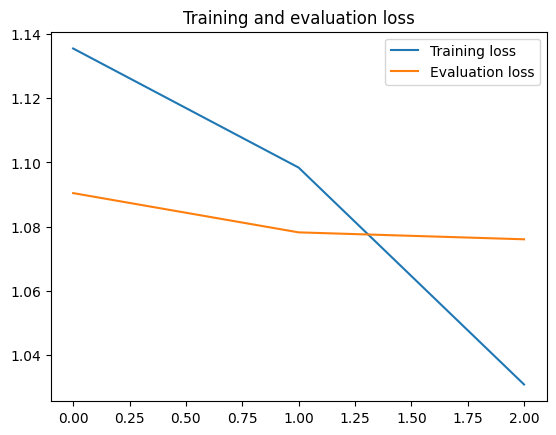

In [14]:
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

# Define model arguments
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True
model_args.evaluate_during_training=True

model_args.num_train_epochs=2
model_args.train_batch_size=16
model_args.learning_rate=12e-6
model_args.max_seq_length=256

model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=8


model = ClassificationModel('bert', 'bert-base-uncased', num_labels=3, args=model_args, use_cuda=False)
_, history = model.train_model(train, eval_df=dev)
model.save_model("saved_topic_model")

# Show the losses of the model
train_loss = history['train_loss']
eval_loss = history['eval_loss']

plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

# Evaluating on the dev set
result, model_outputs, wrong_predictions = model.eval_model(dev)

predictions = np.argmax(model_outputs, axis=1)
true_labels = dev["labels"].values

report = classification_report(
    true_labels,
    predictions,
    target_names=["book", "movie", "restaurant"]
)

print(report)

cm = confusion_matrix(true_labels, predictions)
print("Confusion Matrix:")
print(cm)

## Evaluation and error analysis

In [15]:
print("Naive Bayes")
true_labels = test_df.labels

X_test_counts = count_vect.transform(test_df['text'])
X_test_tfidf = tfidf_transformer.transform(X_test_counts)
nb_preds = nb.predict(X_test_tfidf)

report_nb = classification_report(
    true_labels,
    nb_preds,
    target_names=["book", "movie", "restaurant"]
)

print(report_nb)

cm_nb = confusion_matrix(true_labels, nb_preds)
print("Confusion Matrix:")
print(cm_nb)

Naive Bayes
              precision    recall  f1-score   support

        book       1.00      0.50      0.67         2
       movie       0.80      0.80      0.80         5
  restaurant       0.75      1.00      0.86         3

    accuracy                           0.80        10
   macro avg       0.85      0.77      0.77        10
weighted avg       0.82      0.80      0.79        10

Confusion Matrix:
[[1 1 0]
 [0 4 1]
 [0 0 3]]


Naive Bayes really depends on the topic word being there. When a sentence says movie or restaurant or book directly it gets it right. When it doesn't, it slips.

In [16]:
print("Fine tuned BERT")

result, model_outputs, wrong_predictions = model.eval_model(test_df)

bert_preds = np.argmax(model_outputs, axis=1)
true_labels = test_df["labels"].values

report = classification_report(
    true_labels,
    bert_preds,
    target_names=["book", "movie", "restaurant"]
)

print(report)

cm = confusion_matrix(true_labels, bert_preds)
print("Confusion Matrix:")
print(cm)

Fine tuned BERT


0it [00:00, ?it/s]

/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Running Evaluation:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        book       0.50      0.50      0.50         2
       movie       0.62      1.00      0.77         5
  restaurant       0.00      0.00      0.00         3

    accuracy                           0.60        10
   macro avg       0.38      0.50      0.42        10
weighted avg       0.41      0.60      0.48        10

Confusion Matrix:
[[1 1 0]
 [0 5 0]
 [1 2 0]]


/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jasp/School/Text Mining/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [17]:
# side by side comparison of the two systems on the test sentences
label_names = ["book", "movie", "restaurant"]

comparison = pd.DataFrame({
    'text': test_df['text'].values,
    'gold': [label_names[l] for l in test_df.labels.values],
    'nb': [label_names[l] for l in nb_preds],
    'bert': [label_names[l] for l in bert_preds],
})

comparison[(comparison.gold != comparison.nb) | (comparison.gold != comparison.bert)]

,text,gold,nb,bert
0,It took eight years for Warner Brothers to rec...,movie,restaurant,movie
1,All the New York University students love this...,restaurant,restaurant,book
2,This Italian place is really trendy but they h...,restaurant,restaurant,movie
6,My husband and I moved to Amsterdam 6 years ag...,restaurant,restaurant,movie
9,"I always have loved English novels, but I just...",book,movie,movie


Naive Bayes did better than BERT this time (0.80 vs 0.60). BERT did not learn to predict restaurant at all, all three restaurant sentences ended up as movie or book. This is underfitting: two epochs at a learning rate of 12e-6 on only 90 sentences was not enough for the classifier to train, so it barely moved off its start and fell back on the larger classes (Lab 6 itself used 10 epochs, we ran 2 to keep CPU time down). NB only needs a few topic words per class to start working which is why it does fine. It still slips on the Warner Brothers movie sentence and the English novels book sentence, both have vocabulary that does not overlap much with our training data.